### Hugging Face pipelines for sentiment analysis

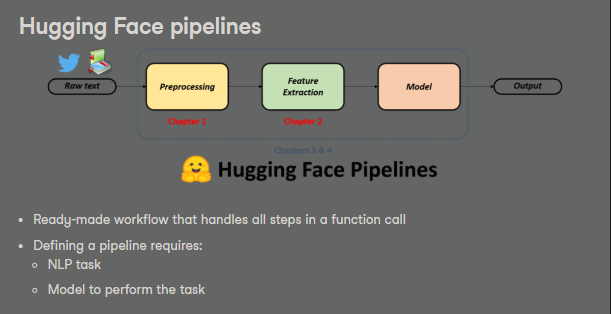

#### Pipelines in code

In [3]:
from transformers import pipeline

classification_pipeline = pipeline(
    task="sentiment-analysis", # or text-classification
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)
result = classification_pipeline("I really liked the movie!!")
print(result)

ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.

In [ ]:
texts = [
    "I really liked the movie!!",
    "Great job ruining my day.",
    "Wow, just what I needed... another problem.",
    "Absolutely fantastic experience!"
]
true_labels = ["POSITIVE", "NEGATIVE", "POSITIVE", "NEGATIVE", "POSITVE"]
results = classification_pipeline(texts)
predicted_labels = [result['label'] for result in results]

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")

Analyzing the sentiment of a review

In [ ]:
from transformers import pipeline

# Define the sentiment analysis pipeline
classifier = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

review_text = "The new update made the app much faster and easier to use!"

# Get sentiment prediction
result = classifier(review_text)

print(result)

Batch classifying multiple reviews

In [ ]:
from transformers import pipeline

classifier = pipeline(task="sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

review_batch = [
    "Absolutely love the new design!",
    "The app crashes every time I open it.",
    "Customer support was helpful and quick.",
    "Too many ads make it unusable.",
    "Everything works fine, but it’s a bit slow."
]

# Classify sentiments
results = classifier(review_batch)
print(results)

Comparing models on labeled review data

In [ ]:
from transformers import pipeline
from sklearn.metrics import accuracy_score
# Load sentiment analysis models
pipe_a = pipeline(task="sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
pipe_b = pipeline(task="sentiment-analysis", model="abilfad/sentiment-binary-dicoding")

# Generate predictions
preds_a = [res['label'] for res in pipe_a(texts)]
preds_b = [res['label'] for res in pipe_b(texts)]

In [ ]:
from transformers import pipeline
from sklearn.metrics import accuracy_score
# Load sentiment analysis models
pipe_a = pipeline(task="sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
pipe_b = pipeline(task="sentiment-analysis", model="abilfad/sentiment-binary-dicoding")

# Generate predictions
preds_a = [res["label"] for res in pipe_a(texts)]
preds_b = [res["label"] for res in pipe_b(texts)]

# Evaluate accuracies
acc_a = accuracy_score(true_labels, preds_a)
acc_b = accuracy_score(true_labels, preds_b)
print(f"Accuracy - Model A: {acc_a:.2f}")
print(f"Accuracy - Model B: {acc_b:.2f}")

Zero-shot classification and QNLI

Zero-shopt classification pipeline

In [5]:
from transformers import pipeline
zero_shot_classifier = pipeline(
    task="zero-shot-classification",
    model="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
)

text = "The national football team won the cup yesterday."
candidate_labels = ["sports", "technology", "health"]
result = zero_shot_classifier(text, candidate_labels)
print(result)

config.json: 0.00B [00:00, ?B/s]

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--MoritzLaurer--DeBERTa-v3-base-mnli-fever-anli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.

Question natural language inference (QNLI)

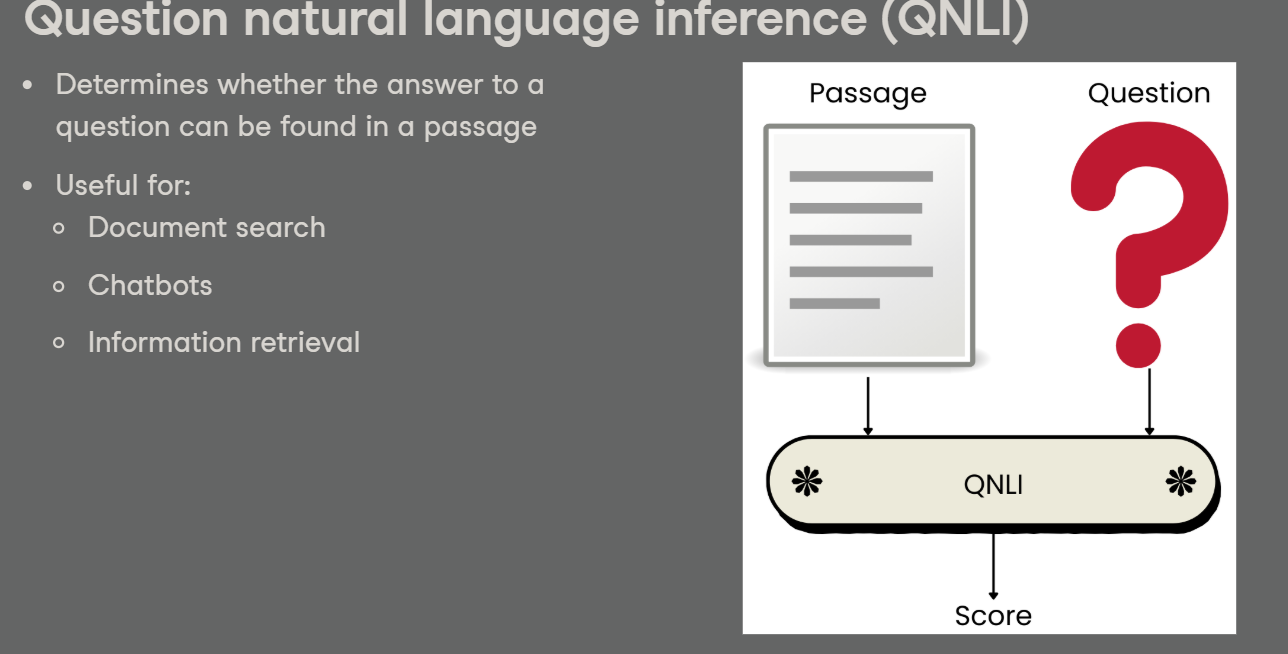

QNLI Pipeline

In [2]:
pip install tf-keras

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 2.6 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 1.8 MB/s eta 0:00:01
   ------------------------------------- -- 1.6/1.7 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.0 MB/s  0:00:01
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 985.3 kB/s eta 0:05:56
   ---------------------------------------- 0.8/351.2 MB 1.2 MB/s eta 0:05:04
   ---------------------------------------- 1.0/351.2 MB 1.1 MB/s eta 0:05:17
   ---------------------------------------- 1

  You can safely remove it manually.


   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------------------------- 0/2 [tensorflow]
   ---------------------

In [4]:
from transformers import pipeline

qnli_pipeline = pipeline(
    task="text-classification",
    model="cross-encoder/qnli-electra-base"
)

passage = "Penguins are found primarily in the Southern Hemisphere."
question = "Where do penguins live?"
result = qnli_pipeline({'text': question, 'text_pair': passage})
print(result)

ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.

In [ ]:
question = "What is the capital of Paris?"
result = qnli_pipeline({"text": question, "text_pair": passage})

# Exercise

Zero-shot classification of support tickets

In [ ]:
from transformers import pipeline

# Initialize the zero-shot classifier
# Classify the ticket
classifier = pipeline(
    task="zero-shot-classification",
    model="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
)

ticket_text = "I was charged twice for my subscription this month. Can you please refund the extra charge?"
candidate_labels = ["Billing", "Technical Issue", "Account Access"]


result = classifier(ticket_text, candidate_labels)

print(result['labels'])
print(result['scores'])

Does the text answer the question?

In [ ]:
from transformers import pipeline

# Initialize the QNLI pipeline
classifier = pipeline(
    task="text-classification",
    model="cross-encoder/qnli-electra-base"
)

passage = "Our refund policy allows customers to return any item within 30 days of purchase, provided the item is in its original condition and accompanied by the receipt. Refunds are issued to the original payment method within 5–7 business days."
question = "Can I get a refund if I return a product after 20 days?"

# Get the result
result = classifier({"text": question, "text_pair": passage})
print(result)